# 5회차 · 모델 평가 & 전처리 — 정확도 너머를 보기

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KimKangSoo123/Github_Colab_Integration_Practice/blob/main/week5/05_evaluation_KKS.ipynb)

**오늘의 목표 (약 2.5시간)**
- 정확도만 보면 안 되는 이유
- 혼동행렬(confusion matrix)
- 정밀도(precision) · 재현율(recall) · F1
- 교차검증(cross-validation)
- ⭐ 스케일링(정규화) 전/후 성능 비교 — 1·2회차 정규화가 실전에서 왜 필요한지

**진행 방식**: 개념 → 예제 실행 → 🔧 빈칸 채우기 순서입니다.

*   혼동행렬(Confusion Matrix) : 인공지능이나 기계학습 모델이 내린 예측 결과가 실제 정답과 얼마나 일치하는지 확인하고 보여주는 표(오차 행렬)

*   정밀도(Precision) 		: 모델이 양성(Positive)이라고 예측한 것 중에서 실제 양성인 데이터의 비율로 거짓 양성(False Positive) 오류를 줄이는 것이 중요할 때 사용.

*   재현율(Recall) 		: 실제 양성인 데이터 중에서 모델이 양성이라고 올바르게 예측한 비율로 민감도라고도 하며 놓치는 실제 양성을 줄이는 것이 중요할 때 사용.

*   F1 스코어(F1 Score)	: 정밀도와 재현율의 조화평균으로 두 지표 어느 한쪽으로 치우치지 않고 균형을 잘 이루고 있는지를 하나의 숫자로 보여줌.

*   교차 검증(cross-validation) : 머신러닝 모델이 새로운 데이터에서도 잘 작동하는지 평가하기 위해, 데이터를 여러 번 나누어 학습과 검증을 반복하는 방법.

*   스케일링(정규화) 		: 서로 다른 크기나 단위를 가진 데이터의 범위를 일정한 기준으로 맞추는 과정

---
## 0. 정확도의 함정

암 환자가 100명 중 3명이라면, 무조건 "정상"이라고만 답해도 정확도 97%입니다. 하지만 정작 환자는 하나도 못 잡죠. 그래서 정확도 외의 지표가 필요합니다. 오늘은 유방암 진단 데이터로 실습해요.

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target   # 0=악성, 1=양성

print("데이터 모양:", X.shape)
print("정답 분포:", pd.Series(y).value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

데이터 모양: (569, 30)
정답 분포: {1: 357, 0: 212}


*   load_breast_cancer 	: 파이썬 머신러닝 라이브러리인 scikit-learn에서 제공하는 유방암 진단 데이터셋을 불러오는 함수

*   train_test_split 		: 전체 데이터를 학습용 데이터(Train set)와 테스트용 데이터(Test set)로 나누어 주는 함수

*   X = pd.DataFrame(data.data, columns=data.feature_names) : 데이터 세트의 숫자 값(data.data)을 가져와 표 모양의 판다스 데이터프레임(pd.DataFrame)으로 바꾸고 각 열의 이름(columns)을 특성 이름(data.feature_names)으로 지정해 변수 X에 저장하는 코드

*   y = data.targe 		: 머신러닝에서 예측해야 하는 정답(출력값)을 의미하며 주로 타깃 데이터(Target), 라벨(Label), 그리고 정답 값을 뜻함.

*   pd.Series(y).value_counts().to_dict() : 데이터 y의 값별 개수를 세어 키(Key)와 값(Value)을 한 쌍으로 묶어서 데이터를 저장하는 딕셔너리(Dictionary) 형태로 바꿈.

---
## 1. 혼동행렬 (Confusion Matrix)

모델이 무엇을 맞히고 무엇을 틀렸는지 4칸 표로 보여줍니다.

[[39  4]
 [ 1 70]]


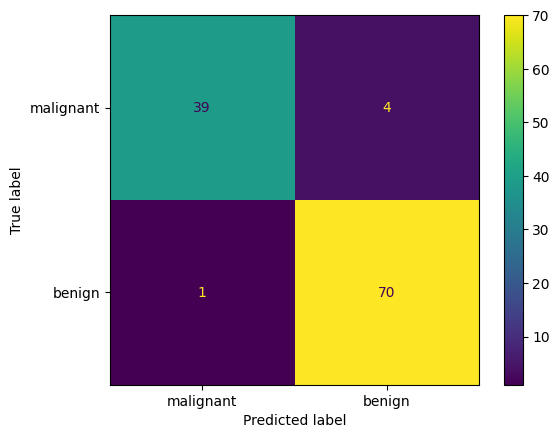

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

cm = confusion_matrix(y_test, pred)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=["malignant", "benign"]).plot()
plt.show()

> 💡 대각선(왼쪽위–오른쪽아래)이 맞힌 것, 나머지가 틀린 것입니다.

*   LogisticRegression 	: 사이킷런(scikit-learn) 라이브러리에서 제공하는 로지스틱 회귀(Logistic Regression) 알고리즘을 구현한 클래스로 데이터가 어떤 범주에 속할지 확률을 예측하여 분류(Classification) 문제를 풀 때 사용

*   confusion_matrix, ConfusionMatrixDisplay : scikit-learn(사이킷 런)의 confusion_matrix, ConfusionMatrixDisplay는 분류 모델의 성능을 평가하고 시각화하기 위한 도구인 혼동 행렬(Confusion Matrix) 계산 함수와 시각화 클래스를 불러오는 코드

*   matplotlib.pyplot 		: 파이썬에서 데이터를 그림이나 그래프로 쉽게 보여주기(시각화) 위해 matplotlib 라이브러리의 pyplot 모듈을 불러옴.

*   confusion_matrix 		: 분류 모델의 성능을 평가하기 위해 실제 정답 값(y_true)과 모델이 예측한 값(y_pred)을 비교하여 오차 행렬(수치 데이터, 2x2와 같은 표 형태) 배열을 계산

    - TP (True Positive)	: 실제 참을 참으로 맞힘(진양성)
    - TN (True Negative)	: 실제 거짓을 거짓으로 맞힘(진음성)
    - FP (False Positive)	: 실제 거짓을 참으로 틀리게 예측함(위양성)
    - FN (False Negative)	: 실제 참을 거짓으로 틀리게 예측함(위음성)

*   .plot() 			: 생성된 객체를 화면에 시각적인 그래프(이미지)로 그려주는 메서드

---
## 2. 정밀도 · 재현율 · F1

- **정밀도(precision)**: "양성이라 예측한 것 중 진짜 양성 비율"
- **재현율(recall)**: "실제 양성 중 모델이 잡아낸 비율" — 암 진단에서 특히 중요
- **F1**: 둘의 균형 점수

`classification_report` 로 한 번에 봅니다.

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred, target_names=["malignant", "benign"]))

              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



*   classification_report 	: 분류(Classification) 모델의 성능을 평가하고 요약해 주는 도구
    - Precision(정밀도) 	: 모델이 참(Positive)이라고 꾼 것 중 진짜 참의 비율
    - Recall(재현율) 		: 실제 참인 것 중 모델이 참이라고 맞춘 비율
    - F1-score 			: 정밀도와 재현율의 조화 평균 (균형 잡힌 지표)
    - Support 			: 테스트 데이터에 포함된 실제 각 클래스의 개수
    - Accuracy 			: 전체 데이터 중 맞게 예측한 비율
    - Macro avg 		: 각 클래스의 지표를 단순 평균한 값
    - Weighted avg 		: 각 클래스의 support, 즉 실제 데이터 개수를 가중치로 사용하여 평균을 계산


### 🔧 과제 2-1
결정트리로 학습·예측한 뒤 `classification_report` 를 출력하세요.

In [11]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)          # TODO: 예측

# TODO: classification_report 출력
print(classification_report(y_test, pred, target_names=["malignant", "benign"]))

              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



*   sklearn.linear_model 	: 선형 기반 예측 모델로 데이터의 특징(feature)과 결과(target) 사이의 선형 조합을 찾아 값을 예측

*   sklearn.tree 		: 트리 구조 기반 모델로 데이터를 여러 기준에 따라 조건문 형태(예/아니오)로 나누어 가며 규칙을 만들어 학습하는 알고리즘을 제공

*   sklearn.metrics 		: Scikit-learn 모델 평가 도구로 학습시킨 모델이 얼마나 잘 작동하는지 평가하고 정답과 예측값을 비교하여 점수를 매기는 함수의 모음

---
## 3. 교차검증 (Cross-Validation)

데이터를 한 번만 나누면 "운 좋게/나쁘게" 나뉠 수 있습니다. 교차검증은 여러 번 나눠 평균을 내 더 믿을 만한 점수를 줍니다.

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=5)
print("5번 점수:", [round(s, 3) for s in scores])
print("평균:", round(scores.mean(), 3))

5번 점수: [np.float64(0.939), np.float64(0.947), np.float64(0.982), np.float64(0.93), np.float64(0.956)]
평균: 0.951


*   cross_val_score 	: 교차 검증(Cross-Validation) 함수로 모델의 성능을 평가하기 위해 데이터셋을 여러 개로 나누고 반복 학습 및 평가를 수행해 점수를 계산

*   cv=5 			: 5-폴드 교차 검증(5-Fold Cross-Validation)로 데이터를 5개로 나누어 교차 검증을 수행하는데 모델을 학습할 때 4개 조각은 공부(훈련)용으로 쓰고 남은 1개 조각은 시험(검증)용으로 사용

*   [round(s, 3) for s in scores] : scores 안의 값을 하나씩 꺼내 s에 넣고, 각 s를 소수점 셋째 자리까지 반올림하여 새로운 리스트를 만든다.

---
## 4. ⭐ 스케일링 전/후 비교

특징들의 값 범위가 제각각이면(어떤 건 0~1, 어떤 건 0~2000) 모델이 헷갈립니다. 그래서 **스케일링(표준화)** 으로 범위를 맞춰줍니다 — 1·2회차에서 손으로 짰던 그 정규화/표준화예요. scikit-learn엔 `StandardScaler` 가 있습니다.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 스케일링 전
m1 = LogisticRegression(max_iter=5000)
m1.fit(X_train, y_train)
acc_before = accuracy_score(y_test, m1.predict(X_test))

# 스케일링 후
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # 학습 데이터로 기준 학습 + 변환
X_test_s = scaler.transform(X_test)         # 테스트는 같은 기준으로 변환만

m2 = LogisticRegression(max_iter=5000)
m2.fit(X_train_s, y_train)
acc_after = accuracy_score(y_test, m2.predict(X_test_s))

print(f"스케일링 전: {acc_before:.3f}")
print(f"스케일링 후: {acc_after:.3f}")

스케일링 전: 0.956
스케일링 후: 0.974


> 💡 `fit_transform` 은 학습 데이터에만, `transform` 은 테스트 데이터에. 테스트 데이터의 정보가 학습에 새어들면 안 되기 때문이에요(중요한 습관!).

*   StandardScaler : 데이터의 평균을 0, 분산을 1(표준정규분포)로 만들어주는(표준화, Standardization) 클래스를 불러오는 코드

*   X_train_s = scaler.fit_transform(X_train) : X_train_s는 표준화된 학습 데이터로 X_train를 fit(X_train 각 열의 평균과 표준편차를 계산), transform(기억한 평균과 표준편차를 이용해 X_train을 표준화)
    - 머신러닝 모델을 학습하는 fit과 다름
    - model.fit(X_train, y_train) : 특징과 정답의 관계를 학습
    - scaler.fit(X_train) : 각 특징 열의 평균과 표준편차만 계산하여 저장 -> scaler는 정답 y_train을 사용하지 않음.

*   X_test_s = scaler.transform(X_test) : X_test_s는 X_test를 표준화하지만, 테스트 데이터에서 새로운 평균과 표준편차를 계산하지는 않음.

*   m2.fit(X_train_s, y_train) 이유 : 표준화를 하면 X의 실제 숫자는 바뀌지만 각 값의 상대적인 위치와 각 행에 대응하는 정답 y의 관계는 유지되어야 하기 때문에 표준화된 입력값 X_train_s와 원래 정답 y_train을 한 쌍으로 모델에 학습시킴.


### 🔧 오늘의 미니 과제 (제출용)
스케일링 전/후의 성능을 **표로 정리**하세요. 정확도뿐 아니라 재현율도 함께 비교합니다.

In [16]:
from sklearn.metrics import recall_score
import pandas as pd

# 전
rec_before = recall_score(y_test, m1.predict(X_test))
# 후  TODO: m2 와 X_test_s 로 재현율 계산
rec_after = recall_score(y_test, m2.predict(X_test_s))

result = pd.DataFrame({
    "구분": ["스케일링 전", "스케일링 후"],
    "정확도": [round(acc_before, 3), round(acc_after, 3)],
    "재현율": [round(rec_before, 3), round(rec_after, 3)],
})
result

,구분,정확도,재현율
0,스케일링 전,0.956,0.986
1,스케일링 후,0.974,0.986


*   recall_score : 재현율(Recall) 을 계산하기 위해 사용하는 함수를 불러오는 코드

---
## 마무리 & 제출

**제출 방법**
1. `런타임 → 모두 실행` 으로 전체를 돌려 결과를 채웁니다.
2. `파일 → GitHub에 사본 저장` → 경로를 `members/본인이름/05_evaluation.ipynb` 로 지정합니다.
3. 커밋 메시지: `5회차 완료`

**복습 팁**: 막혔던 셀 아래에 마크다운 셀을 추가해 "왜 헷갈렸는지"를 한두 줄 적어두면 최고의 복습 노트가 됩니다.


**다음 회차 예고 (6회차)**: 마지막! Keras로 작은 신경망을 만들어 손글씨 숫자(MNIST)를 분류하는 딥러닝을 직접 돌려봅니다.